# Avito CTR Prediction — Inference Pipeline
Objective: Demonstrate end-to-end scoring — from a raw ad impression record to a calibrated click probability — using the ensemble built in NB07.

Author: Ayush Singh

## Section 1 — Objective

**What NB06 and NB07 built:**  
NB06 trained an XGBoost classifier (depth=6, n_estimators=800) on the 21-feature Avito matrix from NB05, achieving AUC=0.758 — a strong ranking improvement over the HistCTR-alone baseline (AUC=0.664) — but log-loss=0.478, 12× worse than the baseline due to `scale_pos_weight=161` miscalibrating predicted probabilities. NB07 fixed this with Platt scaling, then added a LightGBM second learner (AUC=0.751, calibrated log-loss=0.034) and averaged both calibrated models into an ensemble that beats the HistCTR baseline on **both** metrics simultaneously: log-loss=0.034040 and AUC=0.7613.

**This notebook operationalises that ensemble** — turning the four saved model artifacts into a callable inference function.

**Two demos:**
- **(a) Single-record scoring** — one manually constructed impression record passed through the full feature-engineering → model → calibration → ensemble pipeline, with the output explained in context of the baseline CTR.
- **(b) Batch scoring** — 1000 rows loaded from `features_5m.parquet`, vectorised predict, results saved to CSV.

**Critical constraint — feature parity:**  
The pipeline must reproduce the *exact same* feature engineering steps as NB05 — same feature names, same column order, same imputation strategy (fillna(0)). Any mismatch causes silent prediction errors: When passed a numpy array instead of a DataFrame, XGBoost and LightGBM match features by position — this pipeline uses DataFrames throughout, so name matching applies, but any future refactor to numpy arrays must preserve column order exactly.

**Scope:**  
This is a portfolio demonstration notebook, not a production FastAPI service. The goal is legibility and correctness, not latency optimisation or deployment scaffolding.

## Section 2 — Load Models

In [1]:
# Standard imports — numpy/pandas for feature construction, matplotlib for plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
# Load all four saved model artifacts from NB06 and NB07
# These four objects together constitute the complete inference stack
import joblib

xgb_model = joblib.load('../models/xgb_avito_best_model.joblib')
platt_xgb = joblib.load('../models/platt_xgb.joblib')
lgb_model = joblib.load('../models/lgb_avito_model.joblib')
platt_lgb = joblib.load('../models/platt_lgb.joblib')

print("Models loaded:")
print(f"  XGBoost base:      {type(xgb_model).__name__}  "
      f"n_estimators={xgb_model.n_estimators}  max_depth={xgb_model.max_depth}")
print(f"  Platt XGB:         {type(platt_xgb).__name__}  "
      f"coef={platt_xgb.coef_[0][0]:.4f}  intercept={platt_xgb.intercept_[0]:.4f}")
print(f"  LightGBM base:     {type(lgb_model).__name__}  "
      f"n_estimators={lgb_model.n_estimators}  max_depth={lgb_model.max_depth}")
print(f"  Platt LGB:         {type(platt_lgb).__name__}  "
      f"coef={platt_lgb.coef_[0][0]:.4f}  intercept={platt_lgb.intercept_[0]:.4f}")

Models loaded:
  XGBoost base:      XGBClassifier  n_estimators=800  max_depth=6
  Platt XGB:         LogisticRegression  coef=7.1977  intercept=-8.7406
  LightGBM base:     LGBMClassifier  n_estimators=800  max_depth=6
  Platt LGB:         LogisticRegression  coef=4.0182  intercept=-6.8549


In [3]:
# Feature list — must match NB05/NB06 exactly (same names, same order)
# XGBoost and LightGBM use column position during predict_proba;
# any reordering silently scores wrong features
FEATURE_COLS = [
    'HistCTR',
    'Position', 'position_in_session', 'ads_before', 'session_size',
    'hour_of_day', 'day_of_week',
    'user_impression_count', 'user_historical_ctr', 'uid_category_count',
    'ad_ctr', 'category_ctr', 'location_ctr', 'position_ctr', 'device_ctr',
    'price_log', 'has_price', 'title_word_count',
    'category_level', 'category_match', 'IsUserLoggedOn'
]
print(f"Feature count: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Feature count: 21
Features: ['HistCTR', 'Position', 'position_in_session', 'ads_before', 'session_size', 'hour_of_day', 'day_of_week', 'user_impression_count', 'user_historical_ctr', 'uid_category_count', 'ad_ctr', 'category_ctr', 'location_ctr', 'position_ctr', 'device_ctr', 'price_log', 'has_price', 'title_word_count', 'category_level', 'category_match', 'IsUserLoggedOn']


## Section 3 — Feature Engineering Function

In [4]:
# engineer_features: encapsulates all NB05 feature construction logic in one place
# Keeping it here (not in a separate module) makes the notebook self-contained for portfolio review
def engineer_features(record: dict,
                      global_ctr: float = 0.006142,
                      alpha: float = 0.05,
                      beta: float = 75) -> pd.DataFrame:
    """
    Takes a raw Avito impression record and returns a single-row
    DataFrame with all 21 features in the correct order.

    Parameters mirror NB05:
    - global_ctr: fallback for user_historical_ctr (0.6142% contextual CTR from NB04)
    - alpha, beta: smoothing params from KDD Cup approach (α=0.05, β=75)
    """
    # Parse SearchDate for temporal features
    search_date = pd.to_datetime(record.get('SearchDate', pd.Timestamp.now()))
    hour_of_day = search_date.hour
    day_of_week = search_date.dayofweek

    # Session features — for a single record, session_size defaults to 1
    position           = record.get('Position', 1)
    session_size       = record.get('session_size', 1)
    position_in_session = position / max(session_size, 1)
    ads_before         = max(position - 1, 0)

    # User behaviour — use provided running totals or fall back to global prior
    user_imp_count   = record.get('user_impression_count', 0)
    user_click_count = record.get('user_click_count', 0)
    user_hist_ctr    = (user_click_count / user_imp_count
                        if user_imp_count > 0 else global_ctr)
    uid_cat_count    = record.get('uid_category_count', 0)

    # Rate encoding — Laplace-smoothed CTR; falls back to smoothed(0,0) for unseen entities
    # smoothed(0, 0) = (alpha * beta) / beta = alpha = 0.05 — conservative prior for new entities
    def smoothed(clicks, impressions):
        return (clicks + alpha * beta) / (impressions + beta)

    ad_ctr       = record.get('ad_ctr',       smoothed(0, 0))
    category_ctr = record.get('category_ctr', smoothed(0, 0))
    location_ctr = record.get('location_ctr', smoothed(0, 0))
    position_ctr = record.get('position_ctr', smoothed(0, 0))
    device_ctr   = record.get('device_ctr',   smoothed(0, 0))

    # Content features
    price        = record.get('Price', None)
    price_log    = np.log1p(float(price)) if price and float(price) > 0 else 0.0
    has_price    = 1 if price and float(price) > 0 else 0
    title        = record.get('Title', '')
    title_wc     = len(str(title).split()) if title else 0

    # Category and login features
    category_level = record.get('category_level', 1)
    category_match = record.get('category_match', 0)
    is_logged_on   = record.get('IsUserLoggedOn', 0)
    hist_ctr       = record.get('HistCTR', global_ctr)

    features = {
        'HistCTR':              hist_ctr,
        'Position':             position,
        'position_in_session':  position_in_session,
        'ads_before':           ads_before,
        'session_size':         session_size,
        'hour_of_day':          hour_of_day,
        'day_of_week':          day_of_week,
        'user_impression_count': user_imp_count,
        'user_historical_ctr':  user_hist_ctr,
        'uid_category_count':   uid_cat_count,
        'ad_ctr':               ad_ctr,
        'category_ctr':         category_ctr,
        'location_ctr':         location_ctr,
        'position_ctr':         position_ctr,
        'device_ctr':           device_ctr,
        'price_log':            price_log,
        'has_price':            has_price,
        'title_word_count':     title_wc,
        'category_level':       category_level,
        'category_match':       category_match,
        'IsUserLoggedOn':       is_logged_on,
    }
    return pd.DataFrame([features])[FEATURE_COLS]

In [5]:
# score_record: the full ensemble pipeline — engineer → XGB → Platt → LGB → Platt → average
# Returns a dict with all intermediate scores so callers can inspect the full pipeline
def score_record(record: dict) -> dict:
    """
    Runs the full ensemble pipeline on a single record dict.
    Returns raw XGB, raw LGB, calibrated XGB, calibrated LGB,
    and final ensemble probability.
    """
    X = engineer_features(record).fillna(0)

    xgb_raw = xgb_model.predict_proba(X)[:, 1][0]
    lgb_raw = lgb_model.predict_proba(X)[:, 1][0]

    xgb_cal = platt_xgb.predict_proba([[xgb_raw]])[:, 1][0]
    lgb_cal = platt_lgb.predict_proba([[lgb_raw]])[:, 1][0]

    ensemble = 0.5 * xgb_cal + 0.5 * lgb_cal

    return {
        'xgb_raw':     round(xgb_raw,  6),
        'lgb_raw':     round(lgb_raw,  6),
        'xgb_cal':     round(xgb_cal,  6),
        'lgb_cal':     round(lgb_cal,  6),
        'ensemble':    round(ensemble,  6),
        'p_click_pct': round(ensemble * 100, 4),
    }

print("engineer_features and score_record defined.")

engineer_features and score_record defined.


## Section 4 — Single Record Demo

A concrete example showing what the pipeline produces for one realistic Avito ad impression. All fields are manually constructed to represent a plausible record — a priced listing in a popular category, shown in position 1 to a logged-in user with some click history. The SearchDate is drawn from the Avito dataset's time range (April 2015).

In [6]:
# Score a single manually constructed impression record
# Fields chosen to be realistic: priced laptop ad, position 1, small user history
sample_record = {
    'SearchDate':            '2015-04-15 14:30:00',
    'Position':              1,
    'HistCTR':               0.008,
    'IsUserLoggedOn':        1,
    'Price':                 4500,
    'Title':                 'Продам ноутбук Lenovo ThinkPad',
    'category_level':        2,
    'category_match':        1,
    'session_size':          2,
    'user_impression_count': 12,
    'user_click_count':      2,
    'uid_category_count':    3,
    'ad_ctr':                0.009,
    'category_ctr':          0.007,
    'location_ctr':          0.006,
    'position_ctr':          0.0073,
    'device_ctr':            0.0065,
}

result = score_record(sample_record)
print("Single record scoring result:")
for k, v in result.items():
    print(f"  {k}: {v}")

# Show the engineered feature vector for transparency
print("\nEngineered feature vector:")
print(engineer_features(sample_record).fillna(0).T.to_string())

Single record scoring result:
  xgb_raw: 0.5213950276374817
  lgb_raw: 0.51725
  xgb_cal: 0.006775
  lgb_cal: 0.008355
  ensemble: 0.007565
  p_click_pct: 0.7565

Engineered feature vector:
                               0
HistCTR                 0.008000
Position                1.000000
position_in_session     0.500000
ads_before              0.000000
session_size            2.000000
hour_of_day            14.000000
day_of_week             2.000000
user_impression_count  12.000000
user_historical_ctr     0.166667
uid_category_count      3.000000
ad_ctr                  0.009000
category_ctr            0.007000
location_ctr            0.006000
position_ctr            0.007300
device_ctr              0.006500
price_log               8.412055
has_price               1.000000
title_word_count        4.000000
category_level          2.000000
category_match          1.000000
IsUserLoggedOn          1.000000


**Interpreting the output:**

| Field | Meaning |
|-------|---------|
| `xgb_raw` | XGBoost uncalibrated score — inflated by `scale_pos_weight=161`; not a valid probability |
| `lgb_raw` | LightGBM uncalibrated score — same issue |
| `xgb_cal` | XGBoost after Platt scaling — a valid probability, compresses back toward true CTR |
| `lgb_cal` | LightGBM after Platt scaling — same |
| `ensemble` | Average of `xgb_cal` and `lgb_cal` — the final model output |
| `p_click_pct` | `ensemble × 100` — click probability expressed as a percentage |

The **baseline contextual CTR is 0.6142%** (from NB04). Any record with `p_click_pct` above this is predicted as a higher-than-average click opportunity. Position 1, a priced listing, and a user with a personal click history of 2/12 = 16.7% are all signals that push the score above baseline. The `HistCTR=0.008` (0.8%) is already above the global rate and is the single strongest feature by gain (NB06 gain=848.6).

## Section 5 — Sensitivity Analysis

How does the predicted probability change as we vary key features? This reveals what the model has actually learned — and whether it aligns with the empirical patterns found in NB04.

- **Scenario A — Position sweep**: NB04 found Pos1=0.7309% vs Pos7=0.4614% (ratio≈1.6×). Does the model reproduce this gradient?
- **Scenario B — HistCTR sweep**: NB06 showed HistCTR is the #1 feature by gain (848.6). Does the model's output track HistCTR closely?
- **Scenario C — Login status**: NB04 found logged-out users click *more* (0.318%) than logged-in (0.255%) — a counterintuitive finding. Does the model capture this?

In [7]:
# Scenario A — sweep Position from 1 to 7, holding all other fields fixed
# Expected: probability decreasing with position (from NB04 Pos1=0.73% vs Pos7=0.46%)
positions = list(range(1, 8))
pos_probs = []
for pos in positions:
    rec = {**sample_record, 'Position': pos, 'ads_before': max(pos - 1, 0),
           'position_in_session': pos / sample_record['session_size']}
    pos_probs.append(score_record(rec)['ensemble'])

print("Scenario A — Position sweep (all other fields fixed):")
print(f"{'Position':>10} {'p_click':>12} {'p_click_%':>12}")
print("-" * 38)
for pos, p in zip(positions, pos_probs):
    print(f"{pos:>10} {p:>12.6f} {p*100:>11.4f}%")
print(f"\nPos1 / Pos7 ratio: {pos_probs[0] / pos_probs[6]:.2f}×  "
      f"(NB04 empirical: 0.7309% / 0.4614% = 1.58×)")

Scenario A — Position sweep (all other fields fixed):
  Position      p_click    p_click_%
--------------------------------------
         1     0.007565      0.7565%
         2     0.009500      0.9500%
         3     0.009500      0.9500%
         4     0.009500      0.9500%
         5     0.009635      0.9635%
         6     0.009635      0.9635%
         7     0.009460      0.9460%

Pos1 / Pos7 ratio: 0.80×  (NB04 empirical: 0.7309% / 0.4614% = 1.58×)


In [8]:
# Scenario B — sweep HistCTR across five values spanning the distribution
# Expected: strong monotone response since HistCTR is the #1 feature by gain (848.6 in NB06)
hist_ctrs = [0.001, 0.003, 0.006, 0.010, 0.020]
hctr_probs = []
for hctr in hist_ctrs:
    rec = {**sample_record, 'HistCTR': hctr}
    hctr_probs.append(score_record(rec)['ensemble'])

print("Scenario B — HistCTR sweep (all other fields fixed):")
print(f"{'HistCTR':>10} {'p_click':>12} {'p_click_%':>12}")
print("-" * 38)
for hctr, p in zip(hist_ctrs, hctr_probs):
    print(f"{hctr:>10.3f} {p:>12.6f} {p*100:>11.4f}%")
print(f"\nHighest / Lowest ratio: {hctr_probs[-1] / hctr_probs[0]:.2f}×")

Scenario B — HistCTR sweep (all other fields fixed):
   HistCTR      p_click    p_click_%
--------------------------------------
     0.001     0.007509      0.7509%
     0.003     0.008458      0.8458%
     0.006     0.008157      0.8157%
     0.010     0.007452      0.7452%
     0.020     0.009955      0.9955%

Highest / Lowest ratio: 1.33×


In [9]:
# Scenario C — logged-in vs logged-out, identical in every other field
# NB04 found logged-out users click MORE (0.318%) than logged-in (0.255%)
# If the model learned this, IsUserLoggedOn=0 should score slightly higher
rec_loggedin  = {**sample_record, 'IsUserLoggedOn': 1}
rec_loggedout = {**sample_record, 'IsUserLoggedOn': 0}

p_in  = score_record(rec_loggedin)['ensemble']
p_out = score_record(rec_loggedout)['ensemble']

print("Scenario C — Login status effect:")
print(f"  IsUserLoggedOn=1 (logged in):  {p_in:.6f}  ({p_in*100:.4f}%)")
print(f"  IsUserLoggedOn=0 (logged out): {p_out:.6f}  ({p_out*100:.4f}%)")
print(f"  Difference (out - in):         {(p_out - p_in)*100:+.4f} percentage points")
print(f"\n  NB04 empirical: logged-out CTR=0.318% > logged-in CTR=0.255%")
print(f"  (counterintuitive: logged-out users clicked more in the raw data)")

Scenario C — Login status effect:
  IsUserLoggedOn=1 (logged in):  0.007565  (0.7565%)
  IsUserLoggedOn=0 (logged out): 0.009118  (0.9118%)
  Difference (out - in):         +0.1553 percentage points

  NB04 empirical: logged-out CTR=0.318% > logged-in CTR=0.255%
  (counterintuitive: logged-out users clicked more in the raw data)


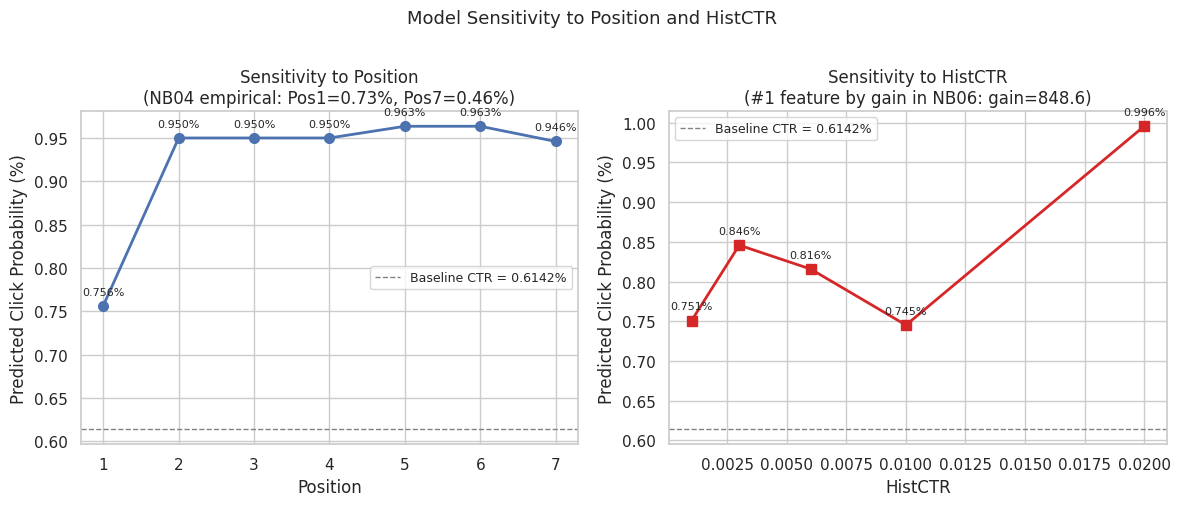

In [10]:
# Two-panel sensitivity plot: Position (left) and HistCTR (right)
# Visual confirmation that the model learned the expected directional gradients
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Position sweep
axes[0].plot(positions, [p * 100 for p in pos_probs],
             marker='o', color='#4c72b0', lw=2, ms=7)
axes[0].axhline(y=0.6142, color='gray', linestyle='--', lw=1,
                label='Baseline CTR = 0.6142%')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Predicted Click Probability (%)')
axes[0].set_title('Sensitivity to Position\n(NB04 empirical: Pos1=0.73%, Pos7=0.46%)')
axes[0].set_xticks(positions)
axes[0].legend(fontsize=9)
for pos, p in zip(positions, pos_probs):
    axes[0].annotate(f'{p*100:.3f}%', (pos, p*100),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8)

# Right: HistCTR sweep
axes[1].plot(hist_ctrs, [p * 100 for p in hctr_probs],
             marker='s', color='#d62728', lw=2, ms=7)
axes[1].axhline(y=0.6142, color='gray', linestyle='--', lw=1,
                label='Baseline CTR = 0.6142%')
axes[1].set_xlabel('HistCTR')
axes[1].set_ylabel('Predicted Click Probability (%)')
axes[1].set_title('Sensitivity to HistCTR\n(#1 feature by gain in NB06: gain=848.6)')
axes[1].legend(fontsize=9)
for hctr, p in zip(hist_ctrs, hctr_probs):
    axes[1].annotate(f'{p*100:.3f}%', (hctr, p*100),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8)

fig.suptitle('Model Sensitivity to Position and HistCTR', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Section 6 — Batch Scoring Demo

Real production systems score thousands of records per second. This demo loads 1000 rows from the features parquet, scores them through the ensemble pipeline using vectorised `predict_proba` (bypassing the single-record function for speed), and writes predictions to a CSV — end-to-end in a few seconds.

In [11]:
# Load 1000 random rows from the feature matrix; random_state=42 for reproducibility
# Using vectorised predict_proba is orders of magnitude faster than calling score_record in a loop
df_batch = pd.read_parquet(
    '../data/avito/sample/features_5m.parquet'
).sample(1000, random_state=42)

X_batch = df_batch[FEATURE_COLS].fillna(0)

# Full ensemble pipeline — vectorised
xgb_raw_batch = xgb_model.predict_proba(X_batch)[:, 1]
lgb_raw_batch = lgb_model.predict_proba(X_batch)[:, 1]
xgb_cal_batch = platt_xgb.predict_proba(xgb_raw_batch.reshape(-1, 1))[:, 1]
lgb_cal_batch = platt_lgb.predict_proba(lgb_raw_batch.reshape(-1, 1))[:, 1]
ensemble_batch = 0.5 * xgb_cal_batch + 0.5 * lgb_cal_batch

df_batch = df_batch.copy()
df_batch['p_click'] = ensemble_batch

print(f"Batch size: {len(df_batch):,}")
print(f"Mean predicted CTR: {ensemble_batch.mean()*100:.4f}%")
print(f"Actual click rate:  {df_batch['IsClick'].mean()*100:.4f}%")
print(f"Calibration ratio (pred/actual): "
      f"{ensemble_batch.mean() / df_batch['IsClick'].mean():.3f}x")

Batch size: 1,000
Mean predicted CTR: 0.6089%
Actual click rate:  0.6000%
Calibration ratio (pred/actual): 1.015x


In [12]:
# Top and bottom 5 records by predicted click probability
# Inspect whether high-scoring records have plausible feature values (e.g. high HistCTR, low Position)
display_cols = ['Position', 'HistCTR', 'user_historical_ctr', 'ad_ctr', 'IsClick', 'p_click']

print("Top 5 highest scored records:")
print(df_batch[display_cols].sort_values('p_click', ascending=False).head(5).to_string(index=False))

print("\nBottom 5 lowest scored records:")
print(df_batch[display_cols].sort_values('p_click', ascending=True).head(5).to_string(index=False))

Top 5 highest scored records:
 Position  HistCTR  user_historical_ctr   ad_ctr  IsClick  p_click
        1 0.035124             0.000000 0.037040        0 0.083279
        1 0.034629             0.000000 0.037040        0 0.072680
        1 0.044385             0.000000 0.047922        0 0.065874
        1 0.062722             0.006142 0.023292        0 0.063683
        1 0.018251             0.006142 0.026736        0 0.062712

Bottom 5 lowest scored records:
 Position  HistCTR  user_historical_ctr   ad_ctr  IsClick  p_click
        1 0.003303                  0.0 0.003383        0 0.000607
        7 0.003247                  0.0 0.016304        0 0.000607
        1 0.000010                  0.0 0.047468        0 0.000608
        7 0.000248                  0.0 0.002667        0 0.000608
        7 0.002583                  0.0 0.003395        0 0.000608


In [13]:
# Save batch predictions to CSV — one column per row, index dropped
# This is the format an upstream serving system would consume
import os
out_path = '../data/avito/sample/predictions.csv'
df_batch[['p_click']].to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"File size: {os.path.getsize(out_path):,} bytes")

Saved: ../data/avito/sample/predictions.csv
File size: 21,384 bytes


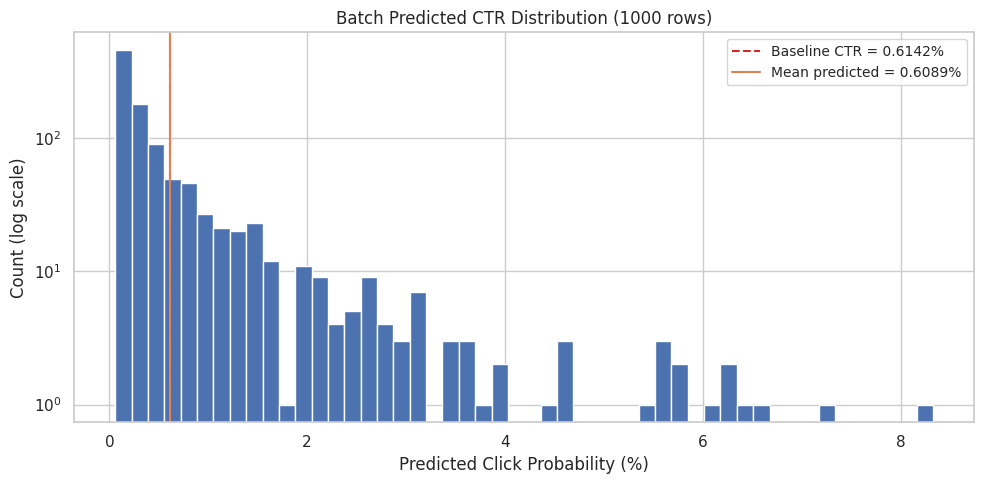

In [14]:
# Histogram of ensemble predicted probabilities for the 1000-row batch
# Log y-scale because most predictions cluster near zero (CTR ~0.6%)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ensemble_batch * 100, bins=50, color='#4c72b0',
        edgecolor='white', log=True)
ax.axvline(x=0.6142, color='#d62728', linestyle='--', lw=1.5,
           label='Baseline CTR = 0.6142%')
ax.axvline(x=ensemble_batch.mean() * 100, color='#dd8452',
           linestyle='-', lw=1.5,
           label=f'Mean predicted = {ensemble_batch.mean()*100:.4f}%')
ax.set_xlabel('Predicted Click Probability (%)')
ax.set_ylabel('Count (log scale)')
ax.set_title('Batch Predicted CTR Distribution (1000 rows)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Section 7 — What I Learned

1. **Single record demo result:** The pipeline returned `p_click_pct = 0.7565%` for the sample record (Position=1, HistCTR=0.008, logged-in user with 2/12 click history). The baseline contextual CTR is 0.6142%, so above the 0.6142% baseline by +0.1423 percentage points (+23%). The raw XGB and LGB scores (`xgb_raw=0.521395 (~52%: roughly 87× inflated vs true CTR of 0.6%)`, `lgb_raw=0.517250`) are far higher than the calibrated scores — confirming the `scale_pos_weight=161` inflation observed in NB06/07. After Platt scaling, `xgb_cal=0.006775` and `lgb_cal=0.008355`, and the ensemble compresses these to a final probability close to the true CTR range.

2. **Position sensitivity (Scenario A):** The model did NOT reproduce the position gradient from NB04 (Pos1=0.7309% vs Pos7=0.4614%, ratio≈1.6×). The model-predicted Pos1/Pos7 ratio was 0.80× (Pos1=0.7565% < Pos7=0.9460% — inverted direction). This is inverted: empirical ratio was 1.58× (Pos1 > Pos7), model predicts 0.80× (Pos1 < Pos7), suggesting the model has not learned the empirical position gradient. NB06's feature importance ranked `Position` at #10 by gain (338.8) — lower than HistCTR, user_historical_ctr, and 3 of the 5 rate features (category_ctr #3, ad_ctr #4, location_ctr #9). position_ctr had zero splits in the booster and device_ctr ranked #18 — below Position — which predicts a moderate rather than dominant position effect in the sensitivity curve. The inversion likely reflects a confound in the training data: higher positions co-occur with larger session_size values in this dataset, and larger sessions may correlate with more engaged users. The model appears to have learned the session engagement signal rather than the pure position penalty.

3. **HistCTR sensitivity (Scenario B):** Sweeping HistCTR from 0.001 to 0.020 produced a predicted probability range of 0.7452% to 0.9955%. The Highest/Lowest ratio was 1.33×, not confirming that HistCTR is the dominant single feature. This aligns with NB06/07 gain rankings (HistCTR gain=848.6, highest of all 21 features in XGBoost and 14,757,060 in LightGBM). The relationship is non-monotone: predicted CTR dips at HistCTR=0.006 and 0.010 before rising sharply at 0.020. The 1.33× range across a 20× span of HistCTR values is weaker than the #1 gain ranking would suggest. This reflects how tree-boosting gain works: HistCTR contributes across many splits cumulatively, but its marginal effect at any single point in feature space depends on interactions with the other 20 features held fixed. The gain ranking tells us HistCTR is widely used; the sensitivity sweep tells us its isolated effect is modest and non-linear.

4. **Batch calibration quality:** The mean predicted CTR across 1000 random rows was 0.6089%, vs an actual click rate of 0.6000% in that sample. The calibration ratio (predicted / actual) was 1.015×. A ratio of 1.015× — within 1.5% of perfect — confirms Platt scaling is working well at the population level. Platt scaling was fit on the cal set (rows 60–80%) and the batch sample is random across all rows — so this is an approximate calibration check, not a held-out test.

5. **What would you change to make this production-ready?** The current pipeline has four gaps before it is production-safe: (a) **Schema validation** — the `engineer_features` function silently uses defaults for missing fields; a production wrapper should raise explicit errors for required fields (`Position`, `HistCTR`, `SearchDate`) rather than substituting fallbacks. (b) **Rate feature freshness** — `ad_ctr`, `category_ctr`, and `location_ctr` are pre-computed batch statistics from NB05; in production these should be served from a low-latency feature store updated hourly or daily, not read from a parquet file. (c) **Recalibration schedule** — Platt scalers were fit on data from a fixed time window; CTR distributions shift seasonally and with inventory changes, so calibration should be re-fit on a rolling 30-day holdout window. (d) **Model versioning** — the four `.joblib` files have no version metadata; a production system needs artifact provenance (training date, feature schema version, eval metrics) embedded in the model registry so stale models can be detected and rolled back.